# Simplified firefighter map

**This notebook was written by generative AI. It's a proof of concept that hasn't been validated; use at your own risk.**

If a map's job is to show which roads connect, how far it is from one place to another, and what'll be hard to get an engine through, then exact geography can be more noise than help. This draws the roads around a rural town as a graph -- intersections and dead ends as nodes, the roads between them as edges -- in the spirit of a subway map, rather than as a map.

- Each road is drawn with its length proportional to its driving distance, so the scale bar measures how far it is to drive.
- Roads are colored by their steepest grade, and sharp turns are marked.
- House numbers are placed along their street, at their distance down it, on the side of the road the house is -- wherever there's room.
- Dead ends, turnarounds, and gates are marked, the same as on the [detailed firefighter map](../detailed/).
- The layout still keeps the rough shape of the area, so places farther north are higher up on the page, and so on.

How it's made is [below](#how-its-made).


In [1]:
import sys
from pathlib import Path

import osmnx as ox

# so the package's modules (in ../../../ptps_wildfire_demo/simplified_map/) can be imported
sys.path.insert(0, str(Path.cwd().parents[2]))
from ptps_wildfire_demo.simplified_map.pipeline import SimplifiedMap

# not committed -- see .gitignore
ox.settings.cache_folder = "data_cache/osmnx"

# a small mountain town west of Boulder, where roads are steep and winding and many homes are down long private drives
gold_hill = SimplifiedMap.build(
    "Gold Hill, Colorado", center=(40.063, -105.409), radius_meters=1200
)

## Whole area

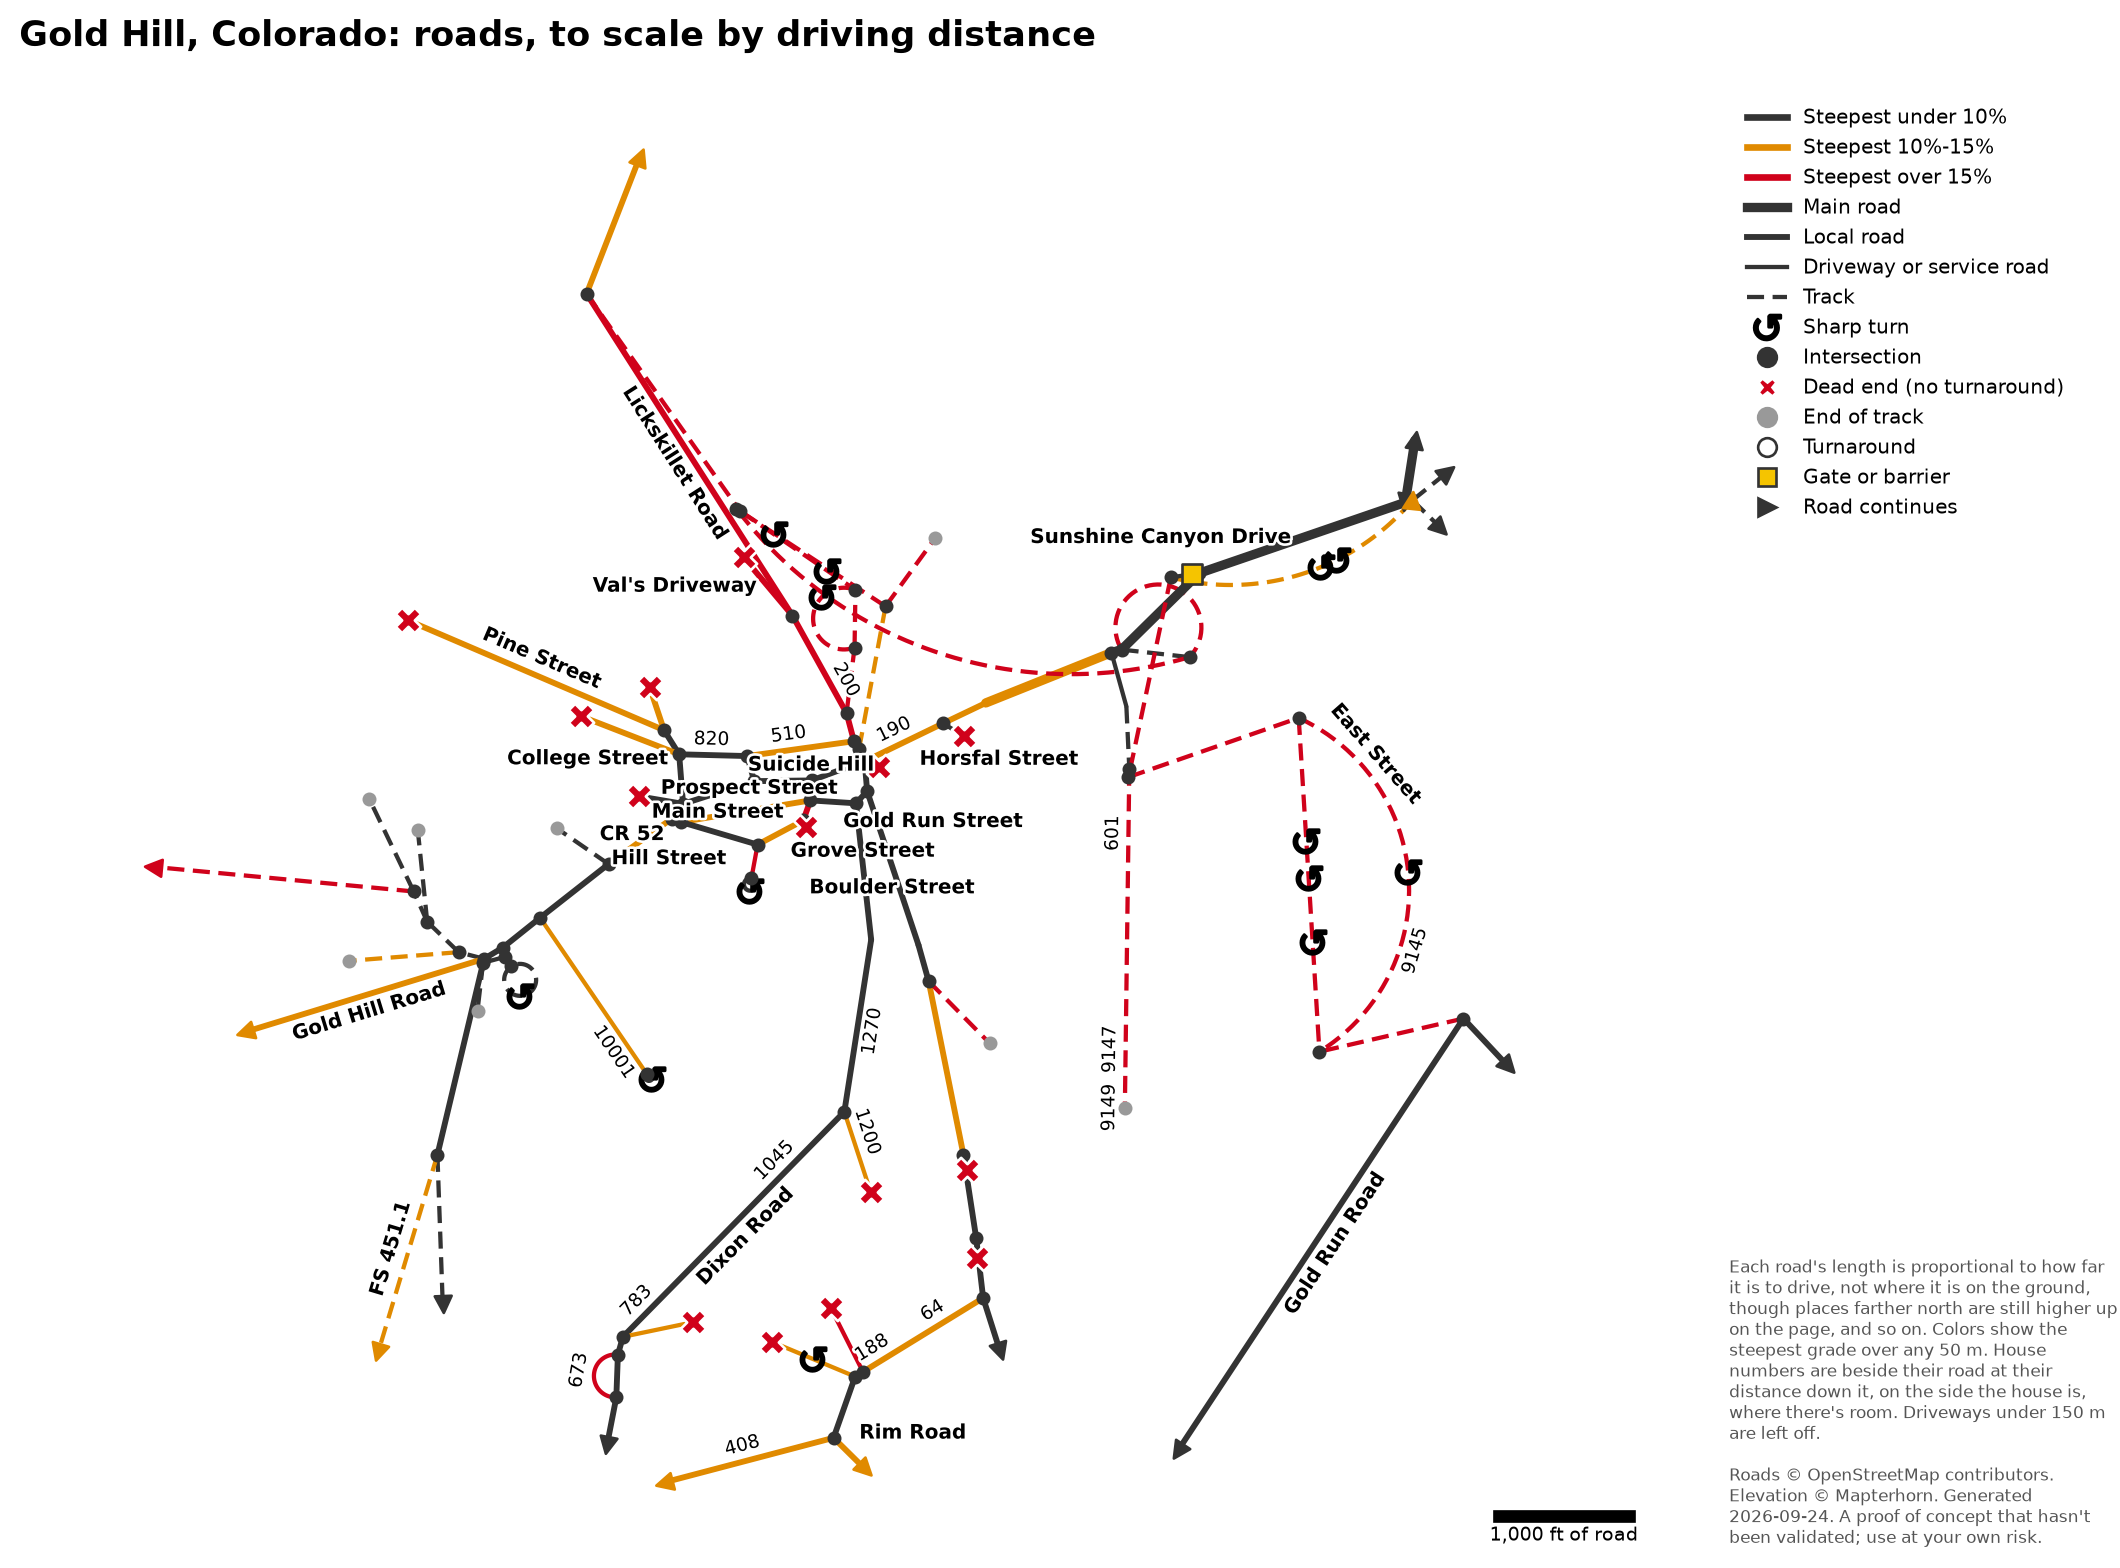

Click to enlarge. The same area on the [detailed firefighter map](../detailed/#15.29/40.06300/-105.40900) and [OpenStreetMap](https://www.openstreetmap.org/#map=15/40.06300/-105.40900).

In [2]:
gold_hill.show()

## Middle of town

At one scale, the town's short blocks get lost next to the long rural roads, so here's the middle of town on its own page, at a larger scale.

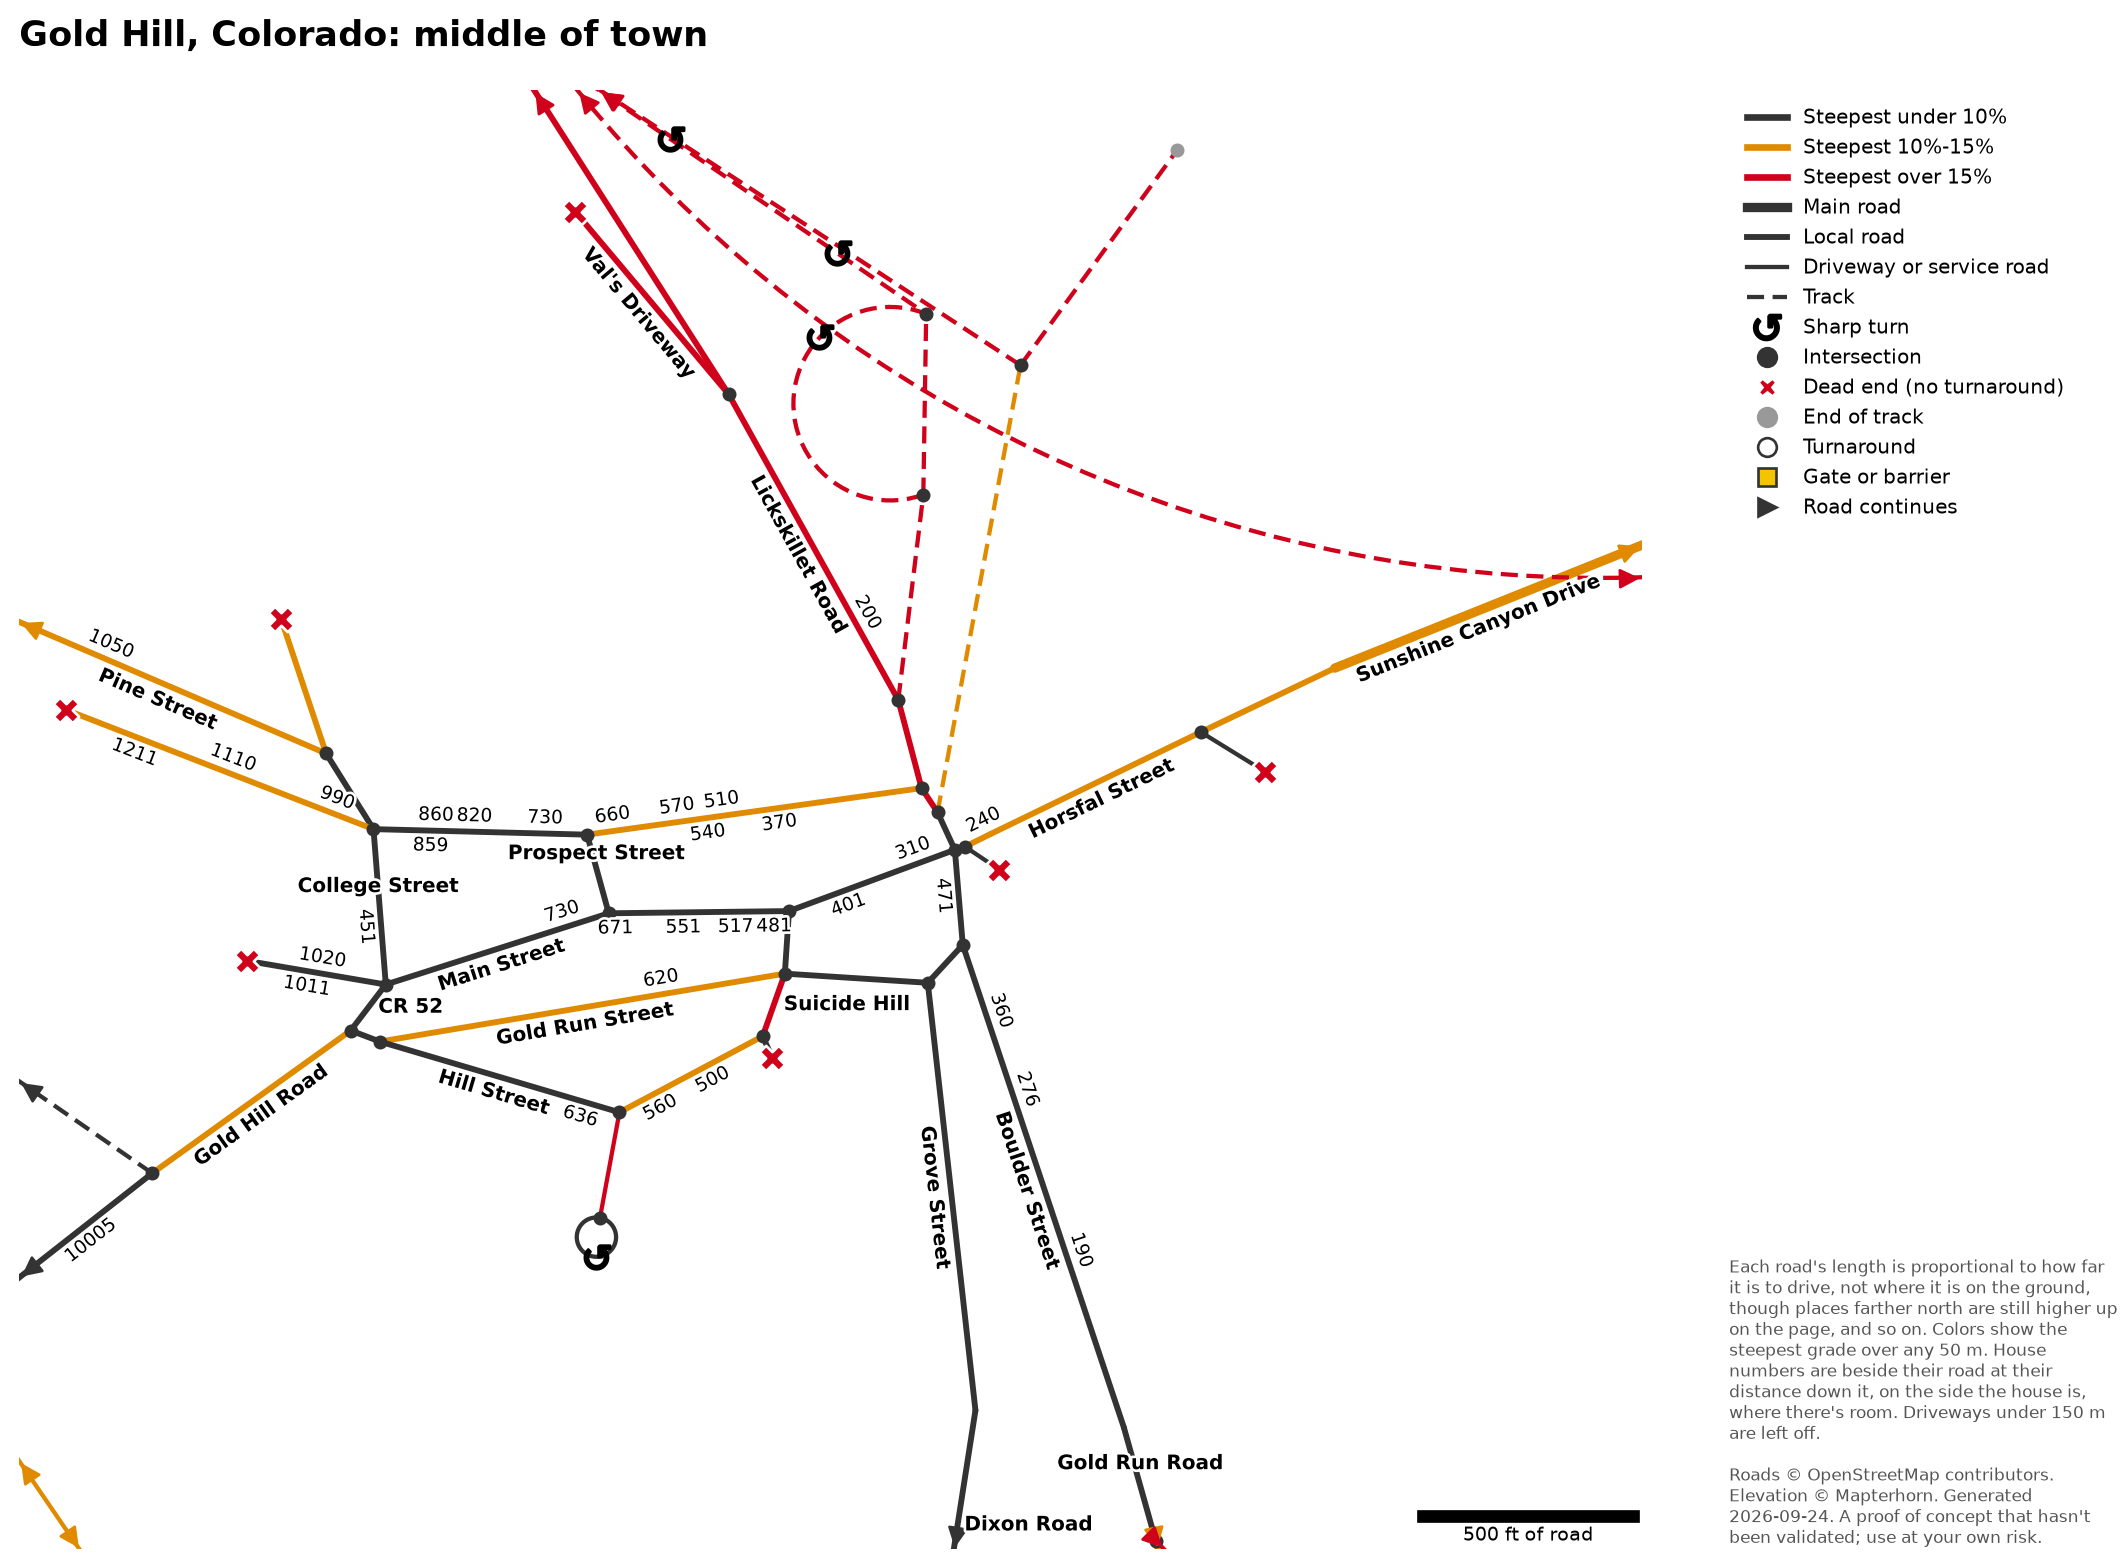

Click to enlarge. The same area on the [detailed firefighter map](../detailed/#16.87/40.06300/-105.40900) and [OpenStreetMap](https://www.openstreetmap.org/#map=17/40.06300/-105.40900).

In [3]:
gold_hill.show(zoomed=True)

## How it's made

The code is in [`ptps_wildfire_demo/simplified_map/`](../../../ptps_wildfire_demo/simplified_map/), where [`pipeline.py`](../../../ptps_wildfire_demo/simplified_map/pipeline.py) runs each step below and has the settings mentioned.

### Road network

Drivable roads from [OpenStreetMap](https://www.openstreetmap.org/copyright), via [OSMnx](https://osmnx.readthedocs.io/). Tracks are included, since engines use them as fire roads. The network is then simplified so the only nodes are intersections, dead ends, gates, and places where a road's name changes, with each stretch of road between two of them as one edge.

Short driveways (under 150 m) that just lead to one house are left off, since they'd outnumber the roads -- the same as the detailed firefighter map's dead ends, since they can be backed out of. Removing them leaves nodes where only two roads meet, so those are merged back into single edges.

### Elevation

From [Mapterhorn](https://mapterhorn.com/)'s open terrain tiles -- the same ones behind the detailed firefighter map's topographic shading, which in the US come from the USGS's [3D Elevation Program](https://www.usgs.gov/3d-elevation-program).

### Grades and sharp turns

Each road is sampled every 10 m along its length. Its grade is the steepest climb over any 50 m stretch, so one noisy elevation sample doesn't read as a cliff. The colors break at 10% -- fire apparatus access roads "shall not exceed 10 percent in grade" under the International Fire Code (Appendix D103.2), unless the fire code official approves otherwise -- and 15%.

A sharp turn is anywhere a road's heading changes by at least 110° from 30 m before to 30 m after -- roughly a curve tighter than a 30 m (100 ft) radius. The tightest spot of each bend is marked.

### Addresses

Addresses from OpenStreetMap -- mapped on the house, or on the building itself -- are placed along the road they're on (their `addr:street`), at the point on that road closest to them, on the side of the road the house is. That makes each one a stop along the road, so the diagram shows how far down the road it is. Addresses with no street, or none that matches a road here, go on the closest road, and ones more than 300 m from any road are left off. A house down one of the long driveways still on the diagram goes on the driveway instead, when the driveway comes off its street, since that's where it's reached from.

### Layout

Rather than where they are on the ground, intersections are placed so that each road's length on the page is proportional to its driving distance -- a curvy half mile and a straight half mile come out the same length. Roads are drawn straight wherever that works out, and as arcs where they can't be (two roads between the same intersections, or a loop).

Positions start out geographic, then are adjusted to fit the road lengths, balanced against two weaker pulls:

- toward each intersection's actual location, so that places farther north stay higher up on the page (and farther east stay farther right) -- the diagram keeps the rough shape of the area, just not its exact distances
- toward keeping every pair of intersections as far apart as the driving distance between them, so unconnected roads don't pile up on each other

### Labels

Every road with a name (or route number) is labeled once, along the road where there's room, or level beside it where there isn't. Labels are placed in order of importance -- road names, then house numbers -- and any that would overlap an earlier one, a symbol, the title, or the edge of the page are left off.

### By the numbers

In [4]:
gold_hill.summary()

- Run 2026-09-24 05:45 UTC
- 104 intersections, dead ends, and gates, joined by 121 roads
- Elevations from 2,054 to 2,720 m
- 52 of 121 roads are steeper than 10% somewhere, and there are 13 sharp turns
- 153 of 156 addresses placed, 11 of them on driveways
- Road lengths on the page are within 2% of scale for 95% of roads, and 6% at worst
- 0.8% of pairs of intersections are out of order north-south, and 0.6% east-west